In [1]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('spaceship-titanic')

print("Path to competition files:", path)

Path to competition files: C:\Users\MSI\.cache\kagglehub\competitions\spaceship-titanic


In [2]:
import shutil
import os

target_dir = r"C:\Users\MSI\Desktop\Spaceship-Titanic\Data"

os.makedirs(target_dir, exist_ok=True)

for file_name in os.listdir(path):
    shutil.move(os.path.join(path, file_name), target_dir)

print("Files moved to:", target_dir)

Files moved to: C:\Users\MSI\Desktop\Spaceship-Titanic\Data


In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

df=pd.read_csv("C:/Users/MSI/Desktop/Spaceship-Titanic/Data/train.csv")
df.head()


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [5]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [6]:
df.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df_cleaned = df.dropna()

In [11]:
df["Transported"].value_counts()

Transported
True     4378
False    4315
Name: count, dtype: int64

In [10]:
df_cleaned["Transported"].value_counts()

Transported
True     3327
False    3279
Name: count, dtype: int64

C:\Users\MSI\AppData\Local\Temp\ipykernel_29268\4098941464.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Transported", data=df_cleaned, palette="Set2")


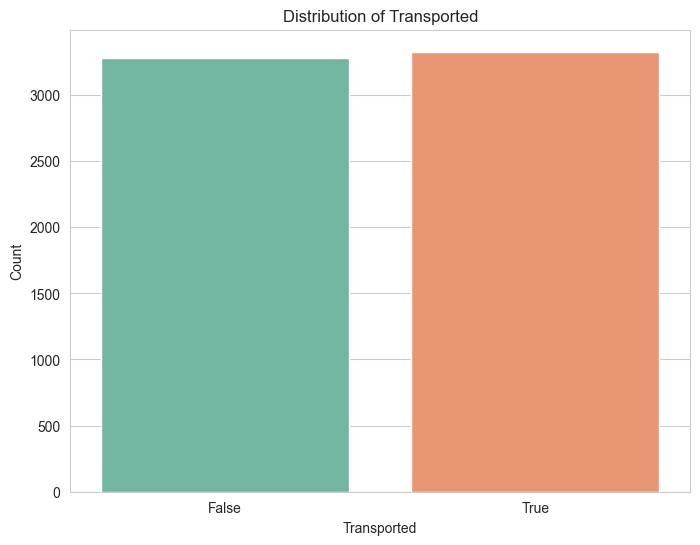

In [13]:
sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))
sns.countplot(x="Transported", data=df_cleaned, palette="Set2")
plt.title("Distribution of Transported")
plt.xlabel("Transported")
plt.ylabel("Count")
plt.show()

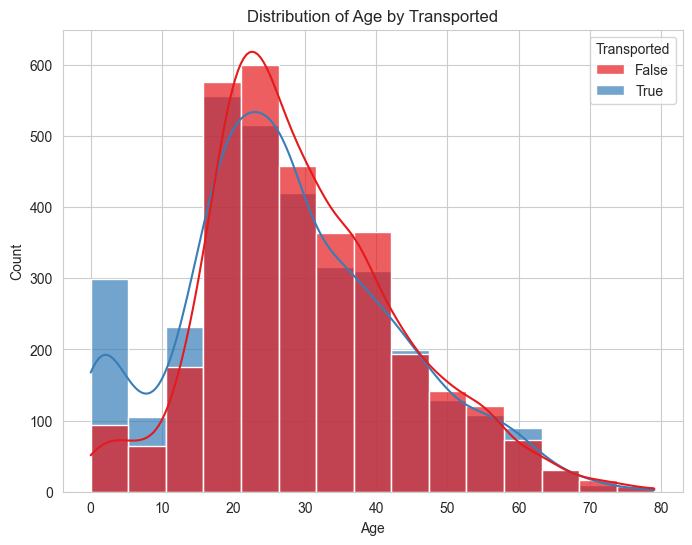

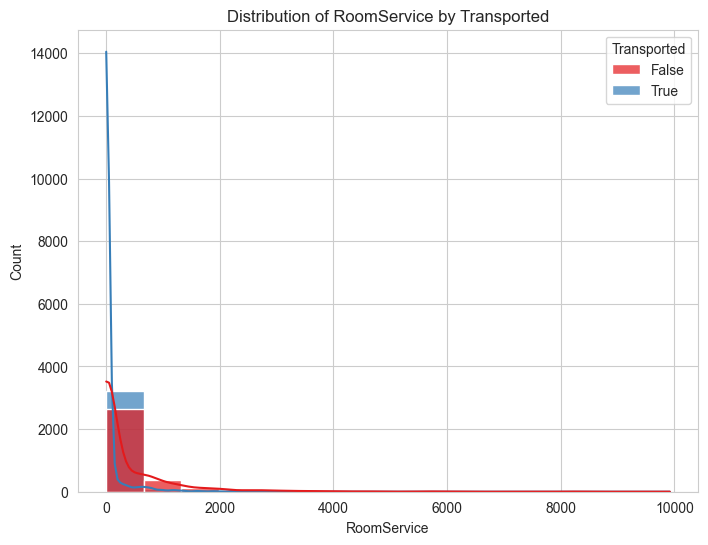

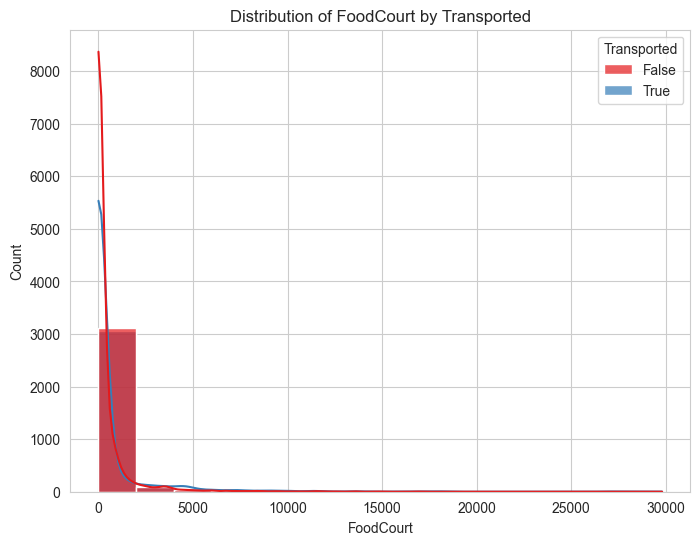

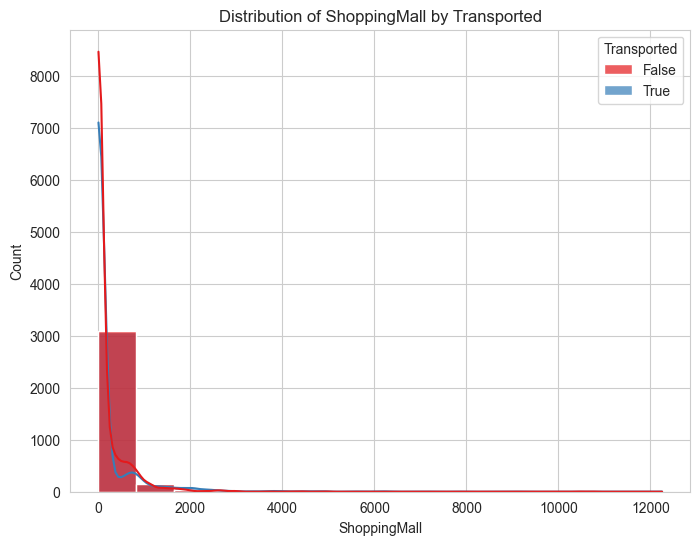

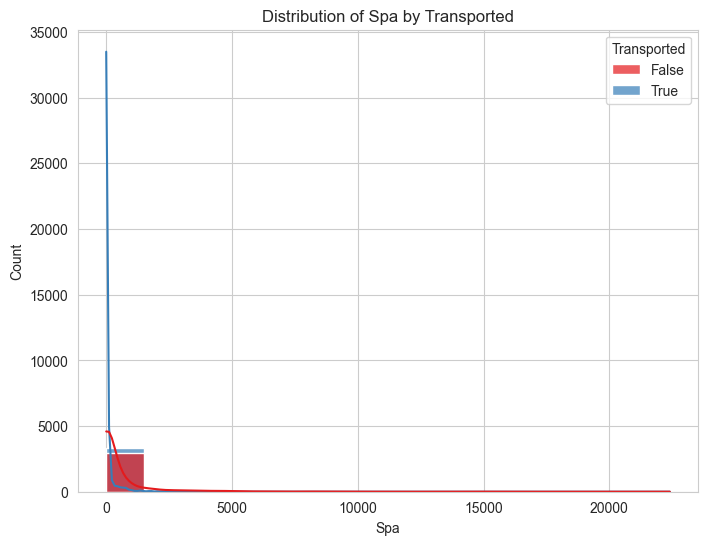

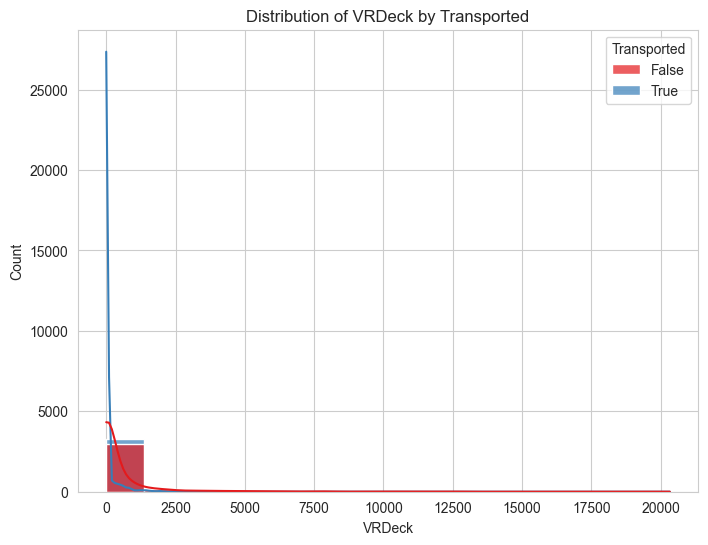

In [16]:
numerical_features = ["Age","RoomService","FoodCourt","ShoppingMall","Spa","VRDeck"]
for feature in numerical_features:
    plt.figure(figsize=(8, 6))
    sns.histplot(df_cleaned, x=feature, hue="Transported", kde=True, palette="Set1", alpha=0.7, bins=15)
    plt.title(f"Distribution of {feature} by Transported")
    plt.show()
    

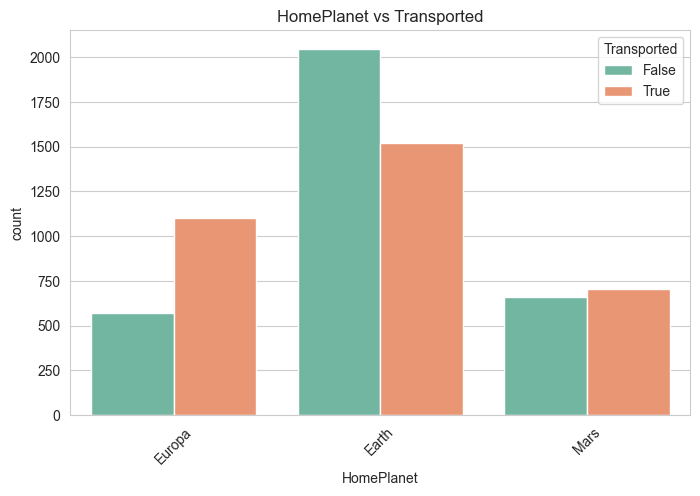

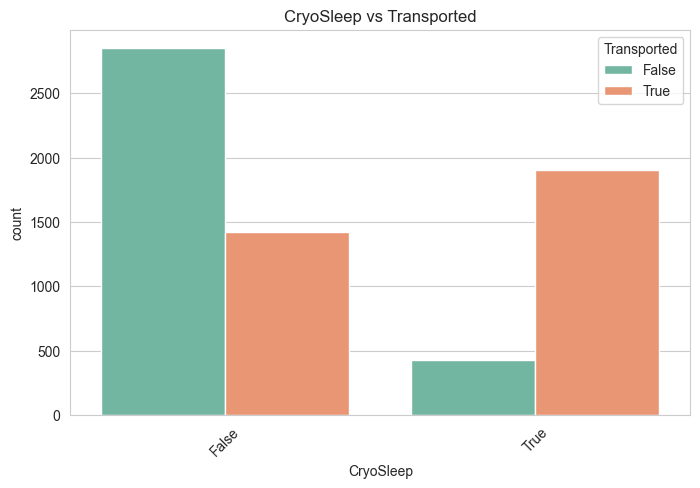

C:\Users\MSI\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


In [ ]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

categorical_features = ["HomePlanet", "CryoSleep", "Cabin", "Destination", "VIP"]

for feature in categorical_features:
    plt.figure()
    sns.countplot(data=df_cleaned, x=feature, hue="Transported", palette="Set2")
    plt.title(f"{feature} vs Transported")
    plt.xticks(rotation=45)
    plt.show()